In [1]:
# Import all libraries.
import os
import numpy as np
import pandas as pd
import json 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
# Initialize Pandas settings.
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)
pd.set_option("display.expand_frame_repr", False)

In [3]:
# Enforce reproducablity.
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [4]:
from sentence_transformers import SentenceTransformer
# model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
model = SentenceTransformer("all-mpnet-base-v2")

/Users/xmastersteel/wally/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8308.94it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [5]:
# # Using Google Colab:
# from google.colab import drive
# drive.mount('/content/drive/')

# DATA_DIR = "/content/drive/MyDrive/CS 489" 
# FILE = os.path.join(DATA_DIR, "CS 489 - Self Playing - Data Collection (1).csv")

# Using local directories:
DATA_DIR = "/Users/xmastersteel/wally/dl" 
FILE = os.path.join(DATA_DIR, "/Users/xmastersteel/wally/dl/data/CS 489 - Self Playing (New).csv")


In [6]:

# Separate dataset into 75/10/15 split.
TRAIN_SPLIT = 0.75 
VAL_SPLIT   = 0.10
TEST_SPLIT  = 0.15
df          = pd.read_csv(FILE)
train_parts, val_parts, test_parts = [], [], []

# Scan through all unique word pairs (30).
for pair_id, group in df.groupby("anchor_left (0)"):
    
    # Extract 15% of total dataset into test set. 
    train_and_val, test = train_test_split(
        group, test_size = TEST_SPLIT, random_state = RANDOM_SEED)
    
    # Extract 10% of remaining 85% for validation split.
    train, val = train_test_split(
        train_and_val, test_size = VAL_SPLIT / (1 - TEST_SPLIT), random_state = RANDOM_SEED)

    train_parts.append(train)
    val_parts.append(val)
    test_parts.append(test)

# Turn train/val/test sets back into singular dfs.
train_df = pd.concat(train_parts).reset_index(drop = True)
val_df   = pd.concat(val_parts).reset_index(drop = True)
test_df  = pd.concat(test_parts).reset_index(drop = True)

print(train_df)
print(val_df)
print(test_df)


         anchor_left (0)  anchor_right (100)                      clue  target               response_list  response_mean  difference    category  Unnamed: 8  Unnamed: 9  Unnamed: 10  Unnamed: 11 Unnamed: 12
0                    Bad                Good           Cutting in line    34.0            33, 27, 12, 8, 8          17.60       16.40  Subjective         NaN         NaN          NaN          NaN         NaN
1                    Bad                Good            Curing disease    91.0          92, 90, 98, 97, 98          95.00        4.00  Subjective         NaN         NaN          NaN          NaN         NaN
2                    Bad                Good        Fostering children    70.0          90, 90, 90, 90, 88          89.60       19.60  Subjective         NaN         NaN          NaN          NaN         NaN
3                    Bad                Good         Community service    76.0          75, 84, 88, 88, 88          84.60        8.60  Subjective         NaN         Na

In [7]:

def cosine_similarity(a, b):
    dot    = np.sum(a * b, axis = 1)
    norm_a = np.linalg.norm(a, axis = 1)
    norm_b = np.linalg.norm(b, axis = 1)
    return dot / (norm_a * norm_b)

def semantic_axis_score(left_enc, right_enc, clue_enc):
    axis          = right_enc - left_enc
    clue_relative = clue_enc  - left_enc
    axis_norm_sq  = np.sum(axis ** 2, axis = 1)
    t             = np.sum(clue_relative * axis, axis = 1) / axis_norm_sq
    return t

# Extract strings from train df.
left_words  = np.array(train_df.loc[:, "anchor_left (0)"])
right_words = np.array(train_df.loc[:, "anchor_right (100)"])
clue_words  = np.array(train_df.loc[:, "clue"])

# Clean NaN values.
left_words  = np.array([str(w) if isinstance(w, str) else "" for w in left_words])
right_words = np.array([str(w) if isinstance(w, str) else "" for w in right_words])
clue_words  = np.array([str(w) if isinstance(w, str) else "" for w in clue_words])

# Richer prompt templates.
left_prompts  = "Something that is clearly " + left_words  + " in nature"
right_prompts = "Something that is clearly " + right_words + " in nature"
clue_prompts  = "The concept or activity known as: "        + clue_words

# Encode strings numerically via sentence transformer.
left_enc  = model.encode(left_prompts,  normalize_embeddings = True)
right_enc = model.encode(right_prompts, normalize_embeddings = True)
clue_enc  = model.encode(clue_prompts,  normalize_embeddings = True)

# Cosine similarities.
left_cos_sim  = cosine_similarity(left_enc,  clue_enc)
right_cos_sim = cosine_similarity(right_enc, clue_enc)

# Improved scores.
delta  = right_cos_sim - left_cos_sim        
scores = semantic_axis_score(left_enc, right_enc, clue_enc)  

for lword, rword, clue, lcs, rcs, d, s in zip(
    left_words, right_words, clue_words,
    left_cos_sim, right_cos_sim, delta, scores
):
    print(f"\n{lword} / {rword} -- {clue}")
    print(f"  left_cos: {lcs:.4f} | right_cos: {rcs:.4f} | delta: {d:.4f} | axis_score: {s:.4f}")


Bad / Good -- Cutting in line
  left_cos: 0.1694 | right_cos: 0.0737 | delta: -0.0957 | axis_score: 0.3476

Bad / Good -- Curing disease
  left_cos: 0.2235 | right_cos: 0.2697 | delta: 0.0462 | axis_score: 0.5736

Bad / Good -- Fostering children
  left_cos: 0.1912 | right_cos: 0.1593 | delta: -0.0319 | axis_score: 0.4491

Bad / Good -- Community service
  left_cos: 0.1506 | right_cos: 0.1644 | delta: 0.0138 | axis_score: 0.5220

Bad / Good -- Selfless heroism
  left_cos: 0.1132 | right_cos: 0.1201 | delta: 0.0068 | axis_score: 0.5108

Bad / Good -- Forgetting birthdays
  left_cos: 0.1337 | right_cos: -0.0053 | delta: -0.1390 | axis_score: 0.2787

Bad / Good -- Feeding homeless
  left_cos: 0.2075 | right_cos: 0.1781 | delta: -0.0294 | axis_score: 0.4532

Bad / Good -- Adopting a pet
  left_cos: 0.2185 | right_cos: 0.1607 | delta: -0.0578 | axis_score: 0.4079

Bad / Good -- Helping a stranger
  left_cos: 0.1633 | right_cos: 0.1510 | delta: -0.0123 | axis_score: 0.4804

Bad / Good -- Th

In [8]:
def axis_projection_predict(left_enc, right_enc, clue_enc):
    axis       = right_enc - left_enc         
    clue_shift = clue_enc  - left_enc          
    proj = np.sum(clue_shift * axis, axis = 1) / (np.linalg.norm(axis, axis = 1) ** 2 + 1e-8)
    return np.clip(proj, 0, 1) * 100

def cos_prediction(left_sim, right_sim):
    total = left_sim + right_sim
    return (right_sim / total) * 100

cos_predictions = cos_prediction(left_cos_sim, right_cos_sim)
cos_mae = np.mean(np.abs(cos_predictions - pd.to_numeric(train_df["response_mean"], errors = "coerce")))
print(f"Baseline MAE: {cos_mae:.2f}")

axis_predictions = axis_projection_predict(left_enc, right_enc, clue_enc)
axis_mae = np.mean(np.abs(axis_predictions - pd.to_numeric(train_df["response_mean"], errors = "coerce")))
print(f"Baseline MAE adjusted: {axis_mae:.2f}")

Baseline MAE: 28.57
Baseline MAE adjusted: 25.86


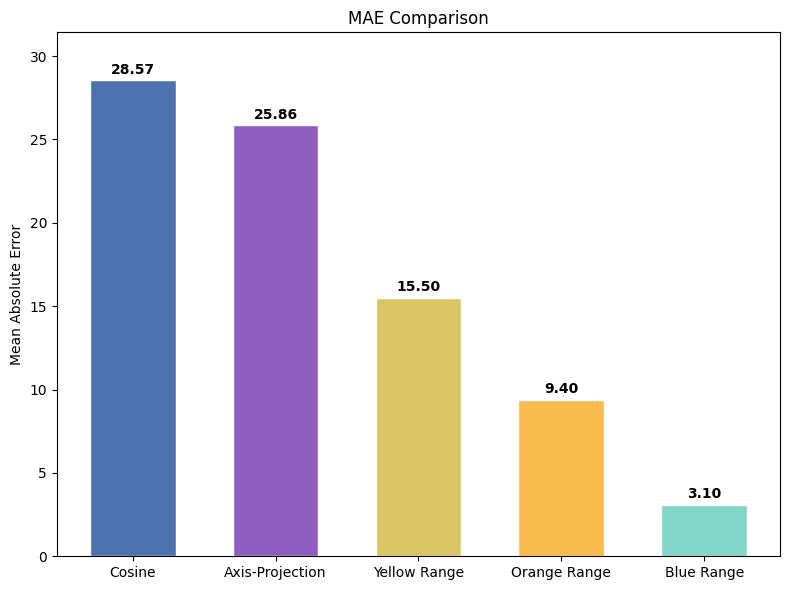

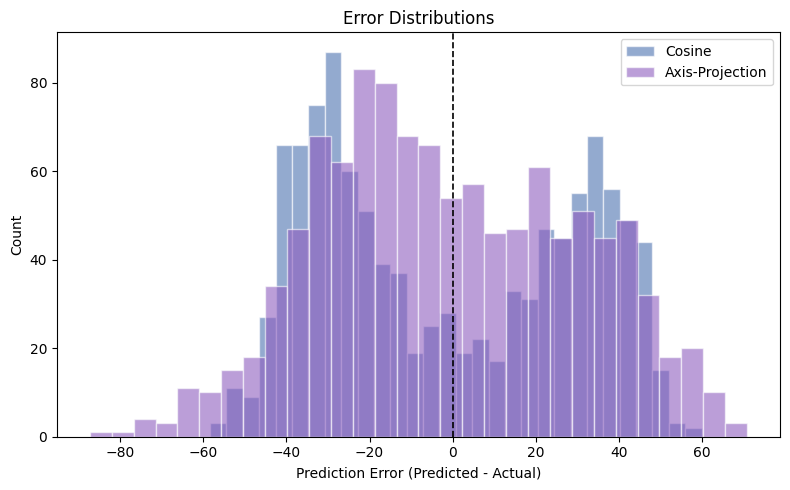

In [9]:
os.makedirs("graphs/baseline", exist_ok = True)

# Ranges I extracted from physical Wavelength game.
BLUE_RANGE_MAE   = 3.1
ORANGE_RANGE_MAE = 9.4
YELLOW_RANGE_MAE = 15.5

# MAE Loss Graph:
fig, ax = plt.subplots(figsize = (8, 6))
bars = ax.bar(["Cosine", "Axis-Projection", "Yellow Range", "Orange Range", "Blue Range"], 
              [cos_mae, axis_mae, YELLOW_RANGE_MAE, ORANGE_RANGE_MAE, BLUE_RANGE_MAE],
              color=["#4C72B0", "#8E5DBF", "#D9C563", "#F9BC4C", "#82D5C9"], width = 0.6, edgecolor = "white")

for bar, val in zip(bars, [cos_mae, axis_mae, YELLOW_RANGE_MAE, ORANGE_RANGE_MAE, BLUE_RANGE_MAE]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            f"{val:.2f}", ha = "center", va = "bottom", fontweight = "bold")

ax.set_ylabel("Mean Absolute Error")
ax.set_title("MAE Comparison")
ax.set_ylim(0, max(cos_mae, axis_mae) * 1.1) 
plt.savefig("graphs/baseline/mae_loss.png", dpi = 150, bbox_inches = "tight")
plt.tight_layout()
plt.show()

# MAE Errors Distribution Graph
cos_errors  = cos_predictions  - pd.to_numeric(train_df["response_mean"], errors = "coerce")
axis_errors = axis_predictions - pd.to_numeric(train_df["response_mean"], errors = "coerce")

# Trim out any outliers, no stretch graph.
cos_clean  = cos_errors[np.abs(cos_errors)   < 3 * np.std(cos_errors)]
axis_clean = axis_errors[np.abs(axis_errors) < 3 * np.std(axis_errors)]

fig, ax = plt.subplots(figsize = (8, 5))  
ax.hist(cos_clean,  bins = 30, color = "#4C72B0", alpha = 0.6, label = "Cosine",          edgecolor = "white")
ax.hist(axis_clean, bins = 30, color = "#8E5DBF", alpha = 0.6, label = "Axis-Projection", edgecolor = "white")
ax.axvline(0, color = "black", lw = 1.2, linestyle = "--")
ax.set_xlabel("Prediction Error (Predicted - Actual)")
ax.set_ylabel("Count")
ax.set_title("Error Distributions")
ax.legend()
plt.savefig("graphs/baseline/mae_error_distribution.png", dpi = 150, bbox_inches = "tight")
plt.tight_layout()
plt.show()

In [10]:
baseline_history = {
    "cos_mae": cos_mae,
    "axis_mae": axis_mae,
    "wavelength_ranges": {
        "blue_range_mae":   BLUE_RANGE_MAE,
        "orange_range_mae": ORANGE_RANGE_MAE,
        "yellow_range_mae": YELLOW_RANGE_MAE
    },
    "cos_predictions": cos_predictions.tolist(),
    "axis_predictions": axis_predictions.tolist(),
    "cos_errors": cos_errors.tolist(),
    "axis_errors": axis_errors.tolist()
}

OUTPUT_PATH = "history/baseline/"
os.makedirs(OUTPUT_PATH, exist_ok = True)
with open(OUTPUT_PATH + "baseline.json", "w") as f:
    json.dump(baseline_history, f, indent = 4)

print(f"Saved to {OUTPUT_PATH + "baseline.json"}")

Saved to history/baseline/baseline.json
